In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os

2026-02-27 17:29:37.525063: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772213377.766499      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772213377.840198      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772213378.399651      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772213378.399718      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772213378.399721      55 computation_placer.cc:177] computation placer alr

In [13]:
d = 3 #hilbert space dimensions

input_dim = d**2
output_dim = d**2
save_dir = f'/kaggle/working/dataset_d{d}'

X_train =np.load(os.path.join(save_dir, "X_train.npy"))
Y_train =np.load(os.path.join(save_dir, "Y_train.npy"))
X_val=np.load(os.path.join(save_dir, "X_val.npy"))
Y_val=np.load(os.path.join(save_dir, "Y_val.npy"))
X_test=np.load(os.path.join(save_dir, "X_test.npy"))
Y_test=np.load(os.path.join(save_dir, "Y_test.npy"))

In [14]:
d = 3 #hilbert space dimensions

input_dim = d**2
output_dim = d**2

model =  models.Sequential(name=f"QST{d}")

model.add(layers.InputLayer(input_shape = (input_dim,)))

model.add(layers.Dense(200,activation ='relu'))
model.add(layers.Dense(180,activation ='relu'))
model.add(layers.Dense(180,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(200,activation ='relu'))

model.add(layers.Dense(output_dim, activation = 'tanh'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2026-02-27 17:34:53.333317: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
optimizer = tf.keras.optimizers.Nadam(
    learning_rate = 0.001,
    beta_1 = 0.9,
    beta_2 = 0.999,
    epsilon = 1e-7
)

model.compile(optimizer=optimizer,
             loss='mse',
             metrics=['mae'])

model.summary()

Model: "QST3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │         2,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 180)            │        36,180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 180)            │        32,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 160)            │        28,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 200)            │        32,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 9)              │         1,809 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,009 (824.25 KB)

 Trainable params: 211,009 (824.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop= callbacks.EarlyStopping(
    monitor='val_loss',
    patience = 200,
    restore_best_weights= True,

    verbose=2
)


checkpoint = callbacks.ModelCheckpoint(
    filepath = f"best_moodel_d{d}.keras",
    monitor = 'vals_loss',
    save_best_only = True,
    verbose = 1
)

history = model.fit(
    X_train, Y_train,
    batch_size = 100,
    epochs = 2000,
    validation_data = (X_val, Y_val),
    callbacks = [early_stop, checkpoint],
    verbose = 1
)

test_loss, test_mae  = model.evaluate(X_test, Y_test, verbose = 0)

print(f"nTest loss (MSE): {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")

model.save(f"final_model_d{d}.keras")

Epoch 1/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0533 - mae: 0.1797 - val_loss: 0.0255 - val_mae: 0.1247
Epoch 2/2000
 8/80 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0234 - mae: 0.1192 

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with vals_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0192 - mae: 0.1067 - val_loss: 0.0116 - val_mae: 0.0785
Epoch 3/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0110 - mae: 0.0763 - val_loss: 0.0096 - val_mae: 0.0709
Epoch 4/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0092 - mae: 0.0697 - val_loss: 0.0111 - val_mae: 0.0769
Epoch 5/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0088 - mae: 0.0681 - val_loss: 0.0071 - val_mae: 0.0607
Epoch 6/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0071 - mae: 0.0604 - val_loss: 0.0052 - val_mae: 0.0488
Epoch 7/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0055 - mae: 0.0525 - val_loss: 0.0100 - val_mae: 0.0791
Epoch 8/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0048 - mae: 0.0485 - val_loss: 0.0039 - val_mae: 0.0416
Epoch 9/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0037 - mae: 0.0416 - val_loss: 0.0029 - val_mae: 0.0344
Epoch 10/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0032 -

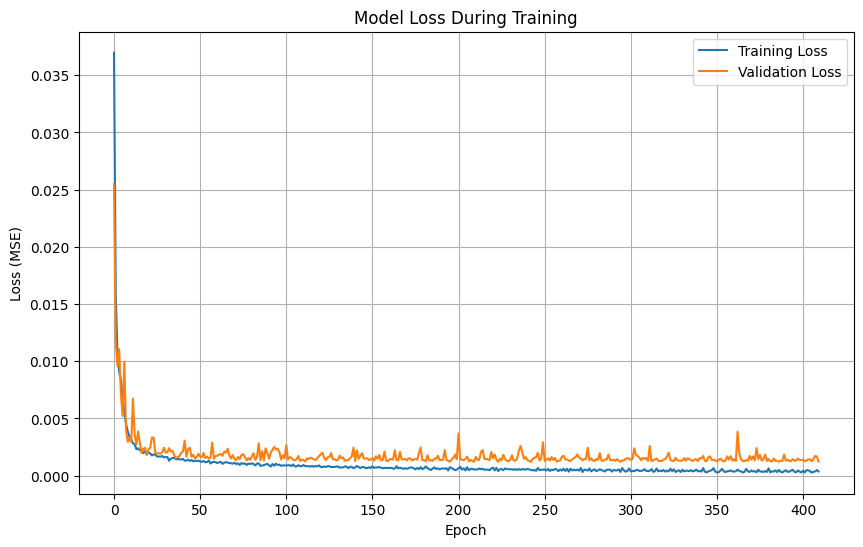

<Figure size 640x480 with 0 Axes>

In [20]:
import matplotlib.pyplot as plt

# Assuming you have 'history' from model.fit()
# history = model.fit(...)

# Plot training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Optional: save the figure
plt.savefig('loss_curve.png')

Metrics recorded: dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


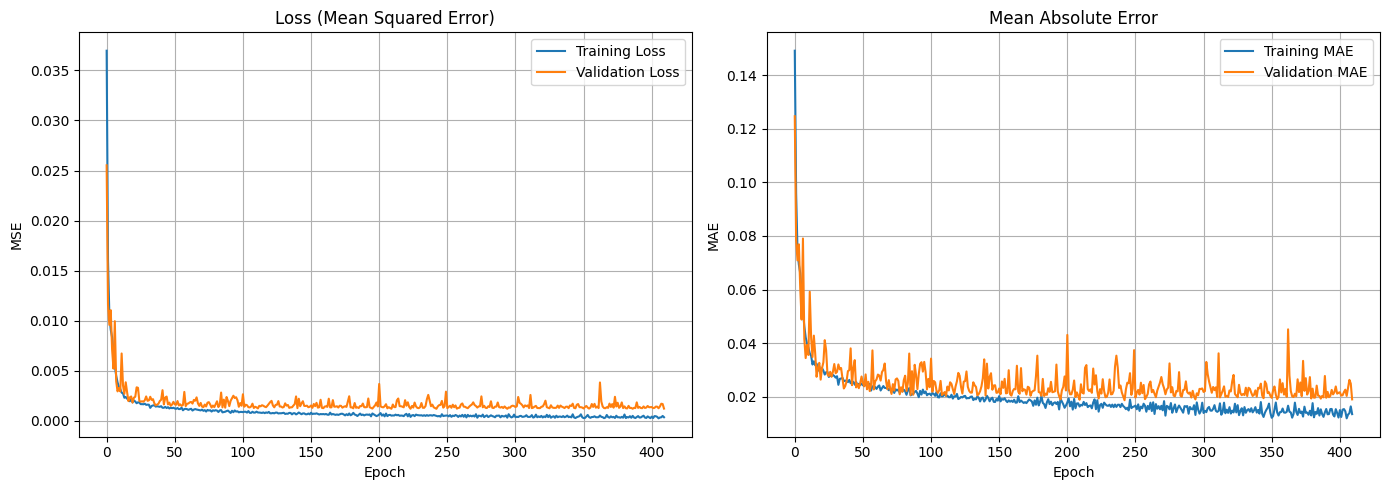

In [21]:
import matplotlib.pyplot as plt

# Assuming you have the 'history' object from model.fit()
# history = model.fit(...)

# Extract the history dictionary
hist = history.history

# Check available metrics (in case you added more)
print("Metrics recorded:", hist.keys())

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Loss (MSE) ---
ax1.plot(hist['loss'], label='Training Loss', linewidth=1.5)
ax1.plot(hist['val_loss'], label='Validation Loss', linewidth=1.5)
ax1.set_title('Loss (Mean Squared Error)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE')
ax1.legend()
ax1.grid(True)

# --- Right plot: MAE ---
ax2.plot(hist['mae'], label='Training MAE', linewidth=1.5)
ax2.plot(hist['val_mae'], label='Validation MAE', linewidth=1.5)
ax2.set_title('Mean Absolute Error')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**D = 7**